# Setup

In [6]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from matplotlib.colors import to_rgba
from globalVars import *
from load_data_pickles import *
from analysis_functions import mean_and_interquartile
from plotting_variables import TINY_SIZE, SMALL_SIZE

# shared Bode plot axis settings
xlim = (0.095, 1.0)
xticks = np.array([0.1, 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
ylimphase = (-np.pi/2, np.pi+1)
yticksphase = [-np.pi/2, 0., np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$', r'$+\pi$']

lowest_x_freq = 8  # number of lowest stimulated frequencies used in norm computations

# frequency-domain signal norms at stimulated frequencies
Y_norm = np.linalg.norm(Ys[:,:,:,IX[:lowest_x_freq]], axis=3)
UH_norm = np.linalg.norm(UHs[:,:,:,IX[:lowest_x_freq]], axis=3)
D_norm = np.linalg.norm(np.asarray(Ds[:,:,:,IX[:lowest_x_freq]]), axis=3)

# human cost: c_H(H,I) = (||y|| + HlamH·||u_H||) / ||d||
HlamH = 1.5  # regularization weight on human effort in the human cost
human_loss_freqdomain = (Y_norm + HlamH*UH_norm) / D_norm


def plot_stats_lines(d1, d2, ax, bplot, box_x, i1, i2, level=0, *, y0, h, lw=0.5, print_ns=False):
    """Paired t-test between d1 and d2; bracket between box indices i1 and i2 (into box_x)."""
    _, p = stats.ttest_rel(d1, d2)
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    if sig == 'ns' and not print_ns:
        return float('-inf')
    x1, x2 = box_x[i1], box_x[i2]
    ax.plot(
        [x1, x1, x2, x2],
        [y0, y0 + h, y0 + h, y0],
        color='black',
        lw=lw,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y0 + h,
        sig,
        ha='center',
        va='bottom',
        fontsize=SMALL_SIZE if sig != 'ns' else TINY_SIZE,
        fontweight='bold' if sig != 'ns' else 'normal',
        clip_on=False,
    )
    return y0 + h


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# load pickle files
with open(data_path +'human_model_fit_data.pkl', 'rb') as file:
    H_2nd_params, H_2nd_fits, H_2nd_params_base, H_2nd_fits_base, H_1st_params, H_1st_fits, H_1st_params_base, H_1st_fits_base = pickle.load(file)
    
with open(data_path +'simulation_results.pkl', 'rb') as f:
    Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D, best_triple = pickle.load(f)


# Second-order human model fit

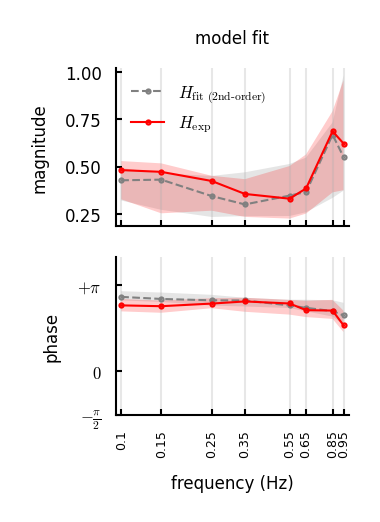

In [8]:
cond = 1
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(1, 1.5), dpi=300)

ax = axs[0]
H_last_3_trials = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]), axis=1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis=0)
ax.plot(freqs, quantile50, '--', marker='.', color='grey', alpha=1, label=r'$H_\text{fit (2nd-order)}$')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='grey', edgecolor='none')

H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]), axis=1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis=0)
ax.plot(freqs, quantile50, '-', marker='.', color='red', alpha=1, label=r'$H_\text{exp}$')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red', edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([])
ax.set_ylabel('magnitude')
ax.set_title('model fit')
ax.tick_params(axis='y')

ax = axs[1]
H_last_3_trials = np.mean(np.angle(-H_2nd_fits[:,cond,15:18,:]), axis=1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis=0)
ax.plot(freqs, quantile50, '--', marker='.', color='grey', alpha=1, label=r'$H_\text{fit}$')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='grey', edgecolor='none')

H_last_3_trials = np.mean(np.angle(-Hs[:,cond,15:18,:][:,:,IX]), axis=1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis=0)
ax.plot(freqs, quantile50, '-', marker='.', color='red', alpha=1, label=r'$H_\text{exp}$')
ax.fill_between(freqs, quantile25, quantile75, alpha=0.2, color='red', edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=90, fontsize=TINY_SIZE-1)
ax.set_ylabel('phase')
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on', axis='x', zorder=-1, alpha=0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left', frameon=False, ncol=1)
plt.show()


In [9]:
# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

print('\n')

# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_1st_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

Correlation: 0.9776303080801209, P-value: 2.1228332343796614e-07
Correlation: 0.9517854993047241, P-value: 6.4782771190450935e-06
Correlation: 0.9032266656802723, P-value: 0.0001386838281942654
Correlation: 0.8800803507820801, P-value: 0.0003516688558712916
Correlation: 0.9909818434518219, P-value: 3.6293365209848913e-09
Correlation: 0.955902306879579, P-value: 4.361503720820029e-06
Correlation: 0.9796335038270968, P-value: 1.3958057447453578e-07
Correlation: 0.9971053763310963, P-value: 2.2018010188861664e-11


Correlation: 0.772560911692577, P-value: 0.0053155832906889855
Correlation: 0.8155452537544134, P-value: 0.0022135888957470888
Correlation: 0.8064162787508935, P-value: 0.0027126788391013505
Correlation: 0.8655124387696302, P-value: 0.0005763528912021303
Correlation: 0.9584572116502945, P-value: 3.3466458120298812e-06
Correlation: 0.9884191608448225, P-value: 1.1143655859901291e-08
Correlation: 0.9480640697887841, P-value: 9.003418445836819e-06
Correlation: 0.9379192058853544, 

# Simulation vs. empirical

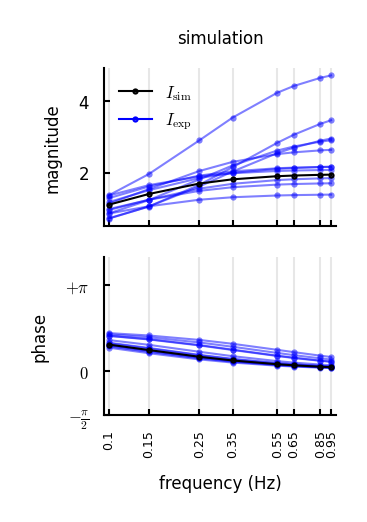

In [10]:
cond = 1
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(1, 1.5), dpi=300)

ax = axs[0]
G_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]), axis=1)
for sub in range(subject_num):
    ax.plot(freqs, G_last_3_trials[sub], '-', marker='.', color='blue', alpha=0.5)
ax.plot(freqs, np.abs(Gs_sim_1st[-1,:]), '-', marker='.', color='black', alpha=1, label=r'$I_\mathrm{sim}$')
ax.plot([], [], color='blue', marker='.', label=r'$I_\mathrm{exp}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([])
ax.set_ylabel('magnitude')
ax.set_title('simulation')
ax.tick_params(axis='y')

ax = axs[1]
G_last_3_trials = np.mean(np.angle(Gs[:,cond,15:18,:]), axis=1)
for sub in range(subject_num):
    ax.plot(freqs, G_last_3_trials[sub], '-', marker='.', color='blue', alpha=0.5)
ax.plot(freqs, np.angle(Gs_sim_1st[-1,:]), '-', marker='.', color='black', alpha=1, label=r'$I_\mathrm{sim}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=90, fontsize=TINY_SIZE-1)
ax.set_ylabel('phase')
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on', axis='x', zorder=-1, alpha=0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left', frameon=False, ncol=1)
plt.show()


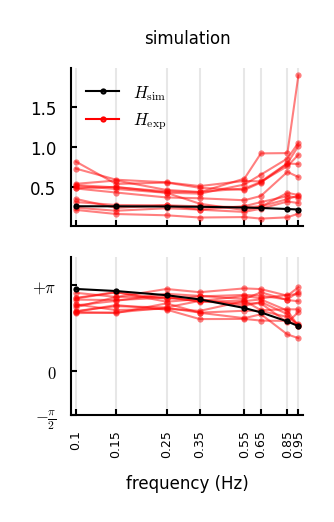

In [11]:
cond = 1
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(1, 1.5), dpi=300)

ax = axs[0]
H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]), axis=1)
for sub in range(subject_num):
    ax.plot(freqs, H_last_3_trials[sub], '-', marker='.', color='red', alpha=0.5)
ax.plot(freqs, np.abs(-Hs_sim_1st[-1,:]), '-', marker='.', color='black', alpha=1, label=r'$H_\mathrm{sim}$')
ax.plot([], [], color='red', marker='.', label=r'$H_\mathrm{exp}$')
ax.set_title('simulation')
ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([])
ax.tick_params(axis='y')

ax = axs[1]
# circular mean of phase to avoid wrapping artefacts
ph = np.mean(np.exp(1j*(np.angle(-Hs[:,cond,15:18,:][:,:,IX]) - np.pi/2)), axis=1)
H_last_3_trials = np.angle(ph) + np.pi/2
for sub in range(subject_num):
    ax.plot(freqs, H_last_3_trials[sub], '-', marker='.', color='red', alpha=0.5)
ax.plot(freqs, np.angle(-Hs_sim_1st[-1,:]), '-', marker='.', color='black', alpha=1, label=r'$H_\mathrm{sim}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=90, fontsize=TINY_SIZE-1)
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on', axis='x', zorder=-1, alpha=0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left', frameon=False, ncol=1)
plt.show()


In [12]:
# Interface, difference between simulated final and experimental (in magnitudes)
for f in range(8):
    G_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]),axis = 1) # avg last 3 adaptive trials 
    mean_emp = np.mean(G_last_3_trials[:,f]) # mean of subjects
    std_emp = np.std(G_last_3_trials[:,f])

    simulated_final = np.abs(Gs_sim_1st[-1,f])
    diff = simulated_final - mean_emp # difference from mean of subjects
    z_score = np.abs(diff / std_emp) # z-score relative to sample SD
    print(f"z-score: {z_score}")
print('\n')
# Human, difference between simulated final and experimental (in magnitudes)
for f in range(8):
    H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # avg last 3 adaptive trials 
    mean_emp = np.mean(H_last_3_trials[:,f]) # mean of subjects
    std_emp = np.std(H_last_3_trials[:,f])

    simulated_final = np.abs(Hs_sim_1st[-1,f])
    diff = simulated_final - mean_emp # difference from mean of subjects
    z_score = np.abs(diff / std_emp) # z-score relative to sample SD
    print(f"z-score: {z_score}")

z-score: 0.2912958291530278
z-score: 0.0902798305686506
z-score: 0.2974486341629909
z-score: 0.4854601515242808
z-score: 0.6133569301992181
z-score: 0.637757694015664
z-score: 0.6624967694239629
z-score: 0.6691925992548892


z-score: 1.191028771008336
z-score: 0.9938134437013204
z-score: 0.967281557751284
z-score: 0.7219576915617117
z-score: 0.751782836224656
z-score: 0.8798526529854527
z-score: 1.3968379673907274
z-score: 1.0616896217218217


# Simulation convergence, change to initial

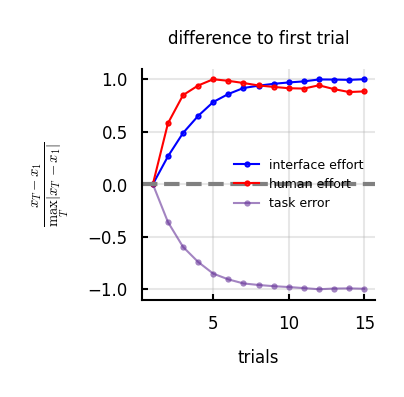

In [13]:
interface_effort_1st = np.sum(abs(freq_domain_UG) ** 2, axis=1)
human_effort_1st = np.sum(abs(freq_domain_UH) ** 2, axis=1)
task_error_1st = np.sum(abs(freq_domain_Y) ** 2, axis=1)

def diff_by_trial0_norm_by_max(y):
    """(y - y0) / max_t |y_t - y0|: deviation from trial 0 scaled by largest absolute change."""
    y = np.asarray(y, dtype=float)
    y0 = float(y[0])
    d = y - y0
    m = float(np.max(np.abs(d)))
    return d / m if m > 0 else d

interface_effort_1st_n = diff_by_trial0_norm_by_max(interface_effort_1st)
human_effort_1st_n = diff_by_trial0_norm_by_max(human_effort_1st)
task_error_1st_n = diff_by_trial0_norm_by_max(task_error_1st)

N_trial = 15

fig, ax = plt.subplots(figsize=(1, 1), dpi=300)
ax.plot(range(1, N_trial+1), interface_effort_1st_n, '-',marker = '.', color='blue', label='interface effort')
ax.plot(range(1, N_trial+1), human_effort_1st_n, '-',marker = '.', color='red', label='human effort')
ax.plot(range(1, N_trial+1), task_error_1st_n, '-', marker = '.', color='rebeccapurple', label='task error', alpha=0.6)
ax.set_xlabel('trials')
ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.set_title('difference to first trial') 
ax.set_ylabel(r'$\frac{x_T - x_1}{\max_T |x_T - x_1|}$',fontsize=TINY_SIZE+1)
ax.set_xticks([5,10,15])
ax.grid(True, alpha=0.3)
ax.tick_params(direction="in")
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))
ax.legend(loc='right',frameon = False, fontsize=TINY_SIZE-1)
plt.show()

# inferred human cost

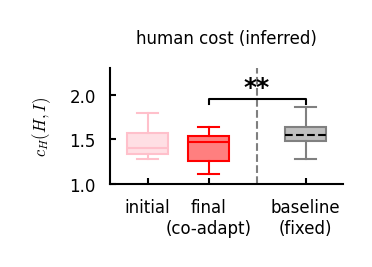

In [14]:
box_labels = ['initial', 'final\n(co-adapt)', 'baseline\n(fixed)']
boxcolors = ['pink', 'red', 'grey']

# initial + final shifted left; baseline right — extra gap before third box
loss_box_x = [0.82, 1.72, 3.15]
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5

fig, ax = plt.subplots(figsize=(1, 0.5), dpi=300)
cond = 1

L = human_loss_freqdomain[:, cond, :]

data = [
    np.mean(L[:, 3:6], axis=1),
    np.mean(L[:, 15:18], axis=1),
    np.mean(L[:, [0,1,2,18,19,20]], axis=1),
]
bplot = ax.boxplot(
    data,
    positions=loss_box_x,
    tick_labels=box_labels,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
ax.set_title('human cost (inferred)', fontsize=TINY_SIZE)
ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)

for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
    patch.set_facecolor(to_rgba(color, alpha=0.5))
    patch.set_edgecolor(color)
    patch.set_linewidth(lw_box)
    bplot['whiskers'][2*i].set_color(color);   bplot['whiskers'][2*i].set_linewidth(lw_box)
    bplot['whiskers'][2*i+1].set_color(color); bplot['whiskers'][2*i+1].set_linewidth(lw_box)
    bplot['caps'][2*i].set_color(color);       bplot['caps'][2*i].set_linewidth(lw_box)
    bplot['caps'][2*i+1].set_color(color);     bplot['caps'][2*i+1].set_linewidth(lw_box)
    bplot['medians'][i].set_color(color);      bplot['medians'][i].set_linewidth(lw_box)

# baseline median always dashed black
bplot['medians'][2].set_color('black')
bplot['medians'][2].set_linestyle('--')
bplot['medians'][2].set_linewidth(lw_box)

plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=1.9, h=0.05)
ax.set_ylim(1, 2.3)

ax.tick_params(axis='x', labelsize=4)
ax.tick_params(direction="in")

# vertical line between final and baseline
ylim = ax.get_ylim()
ax.plot(
    [x_sep_final_baseline, x_sep_final_baseline],
    ylim,
    color='black', linestyle='--', alpha=0.5, linewidth=0.5,
)

ax.set_yticks([1.0, 1.5, 2.0])
ax.set_yticklabels([1.0, 1.5, 2.0])
ax.set_ylabel(r'$c_H(H,I)$')

plt.show()
